In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')

print(df.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [4]:
print(df.isnull().sum())
print("-"*15)
print(df.duplicated().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
---------------
1


In [5]:
df=df.drop_duplicates()

In [6]:
unique_days=df['day'].unique()
unique_smokers=df['smoker'].unique()
unique_time=df['time'].unique()
print(f"Days of the week---> {unique_days}")
print(f"Kind of every meal (breakfast,lunch,dinner)---> {unique_time} ")
print(f"Are there smokers? --->{unique_smokers}")

Days of the week---> ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']
Kind of every meal (breakfast,lunch,dinner)---> ['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner'] 
Are there smokers? --->['No', 'Yes']
Categories (2, str): ['Yes', 'No']


In [7]:
mean_total_bill=df['total_bill'].mean()
print(f"Mean of bill value: {mean_total_bill:.2f}")
print(f"Greatest bill value paid by someone: {df['total_bill'].max()}")
print(f"Lowest bill value paid by someone: {df['total_bill'].min()}")

Mean of bill value: 19.81
Greatest bill value paid by someone: 50.81
Lowest bill value paid by someone: 3.07


In [8]:
result_day=df.groupby('day')['total_bill'].mean()
result_size=df.groupby('size')['total_bill'].mean()
result_sex=df.groupby('sex')['total_bill'].mean()
result_smoker=df.groupby('smoker')['total_bill'].mean()


In [9]:
print(result_day)

day
Thur    17.759508
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


In [10]:
result_size

size
1     7.242500
2    16.470258
3    23.277632
4    28.613514
5    30.068000
6    34.830000
Name: total_bill, dtype: float64

In [11]:
result_smoker

smoker
Yes    20.840652
No     19.188278
Name: total_bill, dtype: float64

In [12]:
result_sex

sex
Male      20.744076
Female    18.115698
Name: total_bill, dtype: float64

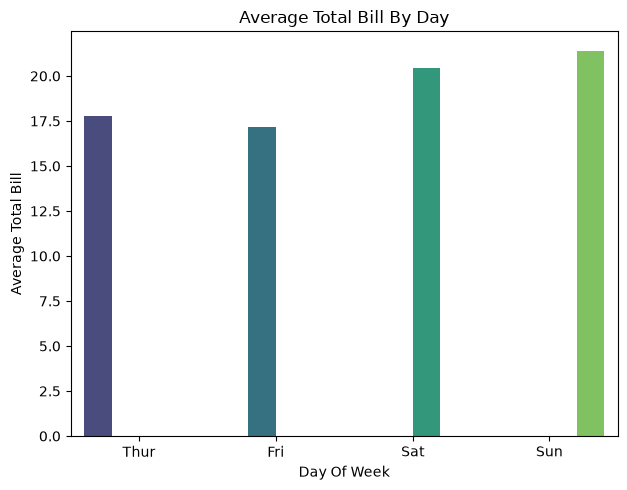

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x='day',y='total_bill',data=df,hue='day',palette='viridis',errorbar=None,legend=False)
plt.title("Average Total Bill By Day")
plt.xlabel("Day Of Week")
plt.ylabel("Average Total Bill")
plt.tight_layout()
plt.show()

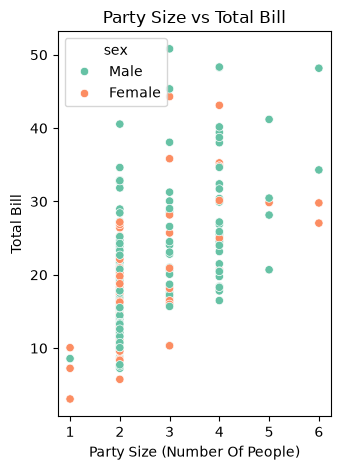

In [14]:
plt.subplot(1,2,2)
sns.scatterplot(x='size',y='total_bill',hue="sex",data=df,palette='Set2')
plt.title("Party Size vs Total Bill")
plt.xlabel('Party Size (Number Of People)')
plt.ylabel('Total Bill')
plt.tight_layout()
plt.show()